In [84]:
# Agrupar por DEPARTAMENTO y calcular estadísticas de VOTOS_VP_PL
estadisticas_por_departamento = df_final.groupby('DEPARTAMENTO')['VOTOS_VP_PL'].agg([
    ('minimo', 'min'),
    ('maximo', 'max'),
    ('promedio', 'mean'),
    ('desviacion_estandar', 'std'),
    ('varianza', 'var')
]).round(4)

print("Estadísticas de VOTOS_VP_PL por DEPARTAMENTO:")
print("="*80)
print(estadisticas_por_departamento)

# Guardar en archivo Excel
estadisticas_por_departamento.to_excel('estadisticas_votos_vp_pl_por_departamento.xlsx')
print("\nArchivo guardado como 'estadisticas_votos_vp_pl_por_departamento.xlsx'")

Estadísticas de VOTOS_VP_PL por DEPARTAMENTO:
                minimo   maximo  promedio  desviacion_estandar  varianza
DEPARTAMENTO                                                            
AMAZONAS       41.1090  97.6196   63.3540              11.3974  129.9001
ANCASH         29.5567  92.3453   66.4448              13.8730  192.4600
APURIMAC       65.3821  95.9852   82.7591               6.7833   46.0129
AREQUIPA       24.4660  95.5056   73.7054              16.5780  274.8310
AYACUCHO       50.8219  96.2631   79.9158              10.3689  107.5144
CAJAMARCA      37.2155  97.8411   74.5072              11.7559  138.2015
CALLAO         11.9504  41.6150   28.3407              10.7244  115.0134
CUSCO          58.2543  97.8882   89.4515               6.8242   46.5699
HUANCAVELICA   39.3643  97.0008   78.7417              11.5364  133.0877
HUANUCO        45.3257  93.7695   76.8645              12.0954  146.2993
ICA            37.0978  81.5365   53.0942               9.2294   85.1826
JUNIN

In [85]:
estadisticas_por_departamento.reset_index().to_excel('estadisticas_2021_por_departamento.xlsx', index=False)
print("Archivo guardado como 'estadisticas_2021_por_departamento.xlsx'")


Archivo guardado como 'estadisticas_2021_por_departamento.xlsx'


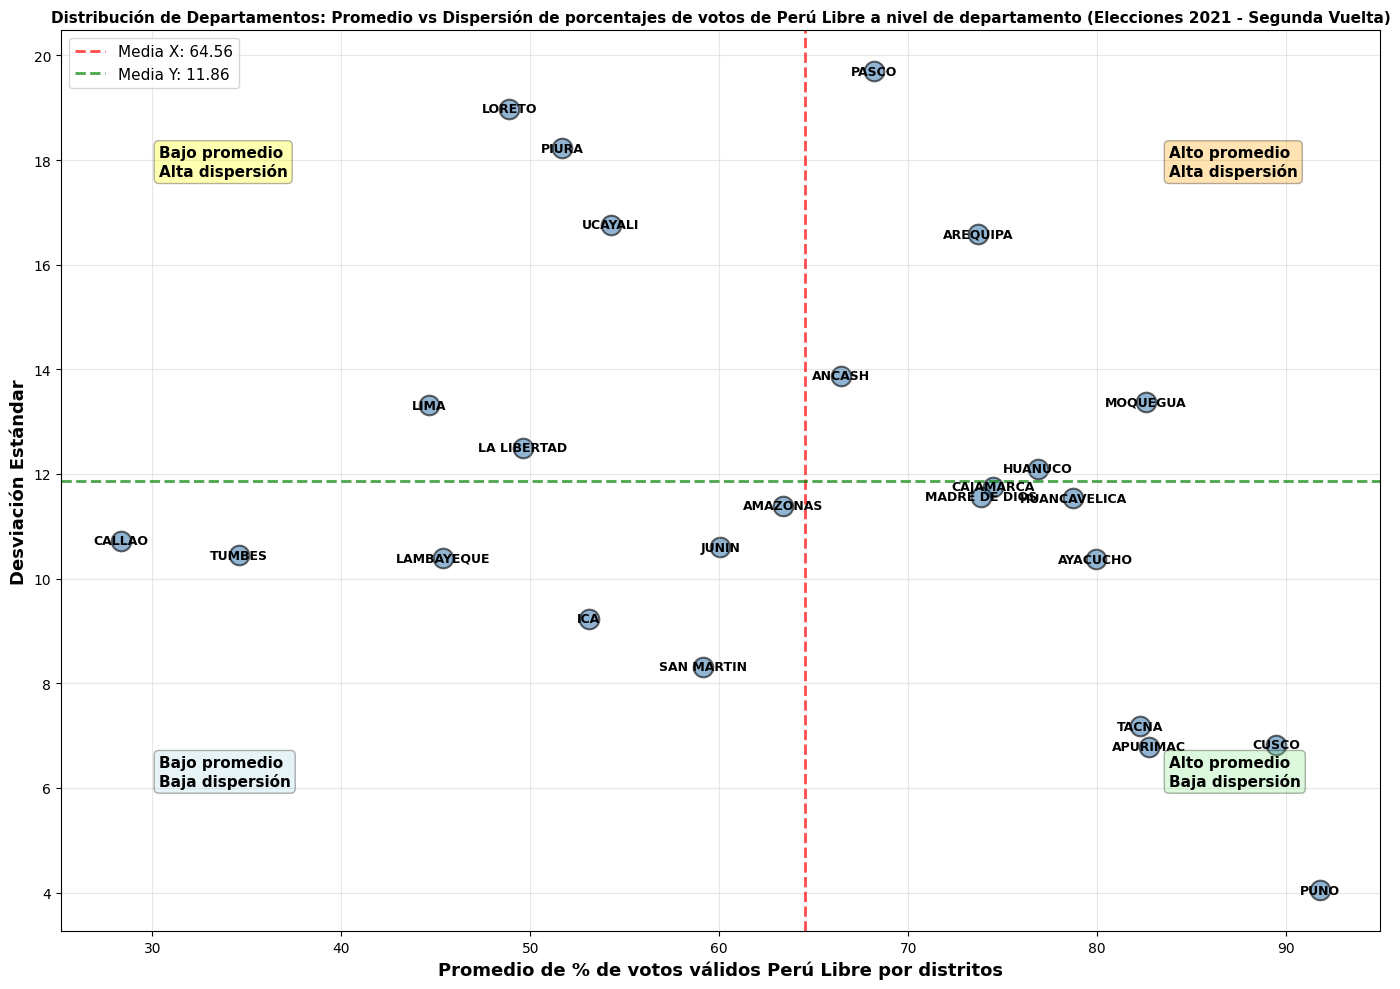

RESUMEN POR CUADRANTES:

Media Promedio: 64.56
Media Desviación Estándar: 11.86


Bajo promedio - Alta dispersión:
Departamentos: ['LA LIBERTAD', 'LIMA', 'LORETO', 'PIURA', 'UCAYALI']
Cantidad: 5

Alto promedio - Alta dispersión:
Departamentos: ['ANCASH', 'AREQUIPA', 'HUANUCO', 'MOQUEGUA', 'PASCO']
Cantidad: 5

Bajo promedio - Baja dispersión:
Departamentos: ['AMAZONAS', 'CALLAO', 'ICA', 'JUNIN', 'LAMBAYEQUE', 'SAN MARTIN', 'TUMBES']
Cantidad: 7

Alto promedio - Baja dispersión:
Departamentos: ['APURIMAC', 'AYACUCHO', 'CAJAMARCA', 'CUSCO', 'HUANCAVELICA', 'MADRE DE DIOS', 'PUNO', 'TACNA']
Cantidad: 8


In [86]:
# Crear gráfico de dispersión con departamentos
fig, ax = plt.subplots(figsize=(14, 10))

# Obtener datos de estadísticas por departamento
x = estadisticas_por_departamento['promedio']
y = estadisticas_por_departamento['desviacion_estandar']
departamentos = estadisticas_por_departamento.index

# Scatter plot
ax.scatter(x, y, s=200, alpha=0.6, color='steelblue', edgecolors='black', linewidth=1.5)

# Agregar etiquetas de departamentos
for i, dept in enumerate(departamentos):
    ax.annotate(dept, (x.iloc[i], y.iloc[i]), fontsize=9, ha='center', va='center', fontweight='bold')

# Calcular media de X y Y para dividir en cuadrantes
media_x = x.mean()
media_y = y.mean()

# Líneas divisoras (cuadrantes)
ax.axvline(x=media_x, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Media X: {media_x:.2f}')
ax.axhline(y=media_y, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Media Y: {media_y:.2f}')

# Etiquetas de cuadrantes
ax.text(x.min() + 2, y.max() - 2, 'Bajo promedio\nAlta dispersión', fontsize=11, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
ax.text(x.max() - 8, y.max() - 2, 'Alto promedio\nAlta dispersión', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
ax.text(x.min() + 2, y.min() + 2, 'Bajo promedio\nBaja dispersión', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(x.max() - 8, y.min() + 2, 'Alto promedio\nBaja dispersión', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# Configurar etiquetas y título
ax.set_xlabel('Promedio de % de votos válidos Perú Libre por distritos', fontsize=13, fontweight='bold')
ax.set_ylabel('Desviación Estándar', fontsize=13, fontweight='bold')
ax.set_title('Distribución de Departamentos: Promedio vs Dispersión de porcentajes de votos de Perú Libre a nivel de departamento (Elecciones 2021 - Segunda Vuelta)', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Imprimir resumen de departamentos por cuadrante
print("RESUMEN POR CUADRANTES:")
print("=" * 80)
print(f"\nMedia Promedio: {media_x:.2f}")
print(f"Media Desviación Estándar: {media_y:.2f}\n")

cuadrantes = {
    'Bajo promedio - Alta dispersión': estadisticas_por_departamento[(x < media_x) & (y >= media_y)],
    'Alto promedio - Alta dispersión': estadisticas_por_departamento[(x >= media_x) & (y >= media_y)],
    'Bajo promedio - Baja dispersión': estadisticas_por_departamento[(x < media_x) & (y < media_y)],
    'Alto promedio - Baja dispersión': estadisticas_por_departamento[(x >= media_x) & (y < media_y)]
}

for cuadrante, datos in cuadrantes.items():
    print(f"\n{cuadrante}:")
    print(f"Departamentos: {list(datos.index)}")
    print(f"Cantidad: {len(datos)}")

In [87]:
# Leer el archivo y obtener los valores únicos de DEPARTAMENTO
df_2011 = pd.read_excel('2011_SEP2011_Presidencial.xlsx')

# Obtener casos únicos por DEPARTAMENTO
departamentos_unicos = df_2011['DEPARTAMENTO'].unique()

print("Departamentos únicos en la base de datos:")
print(departamentos_unicos)
print(f"\nTotal de departamentos únicos: {len(departamentos_unicos)}")

Departamentos únicos en la base de datos:
<StringArray>
[      'UCAYALI',        'TUMBES',         'TACNA',      'MOQUEGUA',
    'SAN MARTIN',          'PUNO',         'PIURA',    'LAMBAYEQUE',
         'PASCO', 'MADRE DE DIOS',        'LORETO',          'LIMA',
        'EUROPA',        'AFRICA',       'AMERICA',          'ASIA',
       'OCEANIA',           'ICA',   'LA LIBERTAD',         'JUNIN',
       'HUANUCO',        'ANCASH',  'HUANCAVELICA',         'CUSCO',
        'CALLAO',     'CAJAMARCA',      'AYACUCHO',      'AREQUIPA',
      'APURIMAC',      'AMAZONAS']
Length: 30, dtype: str

Total de departamentos únicos: 30


In [88]:
# Filtrar el dataframe df_2011 para eliminar filas con departamentos en el exterior
df_2011 = df_2011[~df_2011['DEPARTAMENTO'].isin(['EUROPA', 'AFRICA', 'AMERICA', 'ASIA', 'OCEANIA'])]

print(f"Filas restantes después de filtrar: {df_2011.shape[0]}")
print(f"Departamentos únicos: {df_2011['DEPARTAMENTO'].nunique()}")
print(df_2011['DEPARTAMENTO'].unique())

Filas restantes después de filtrar: 103616
Departamentos únicos: 25
<StringArray>
[      'UCAYALI',        'TUMBES',         'TACNA',      'MOQUEGUA',
    'SAN MARTIN',          'PUNO',         'PIURA',    'LAMBAYEQUE',
         'PASCO', 'MADRE DE DIOS',        'LORETO',          'LIMA',
           'ICA',   'LA LIBERTAD',         'JUNIN',       'HUANUCO',
        'ANCASH',  'HUANCAVELICA',         'CUSCO',        'CALLAO',
     'CAJAMARCA',      'AYACUCHO',      'AREQUIPA',      'APURIMAC',
      'AMAZONAS']
Length: 25, dtype: str


In [89]:
print(df_2011.columns.tolist())

['UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'TIPO_ELECCION', 'MESA_DE_VOTACION', 'DESCRIP_ESTADO_ACTA', 'TIPO_OBSERVACION', 'N_CVAS', 'NELEC_HABIL', 'VOTOS_P1', 'VOTOS_P2', 'VOTOS_VB', 'VOTOS_VN', 'VOTOS_VI']


In [90]:
# Eliminar columnas innecesarias del dataframe df_2011
columnas_a_eliminar = ['TIPO_ELECCION', 'MESA_DE_VOTACION', 'DESCRIP_ESTADO_ACTA', 'TIPO_OBSERVACION', 'N_CVAS', 'NELEC_HABIL']

df_2011 = df_2011.drop(columns=columnas_a_eliminar, errors='ignore')

print("Columnas restantes en df_2011:")
print(df_2011.columns.tolist())
print(f"\nForma del dataframe: {df_2011.shape}")
print("\nPrimeras filas:")
print(df_2011.head())

Columnas restantes en df_2011:
['UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'VOTOS_P1', 'VOTOS_P2', 'VOTOS_VB', 'VOTOS_VN', 'VOTOS_VI']

Forma del dataframe: (103616, 9)

Primeras filas:
   UBIGEO DEPARTAMENTO         PROVINCIA  DISTRITO  VOTOS_P1  VOTOS_P2  \
0  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        44        51   
1  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        46        62   
2  250101      UCAYALI  CORONEL PORTILLO  CALLERIA         0         0   
3  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        32        56   
4  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        94       103   

   VOTOS_VB  VOTOS_VN  VOTOS_VI  
0         2         6         0  
1         1         4         0  
2         1        51         0  
3         2        29         0  
4         0         7         0  


In [62]:
# Agrupar por UBIGEO: sumar votos y conservar las demás columnas
df_2011 = df_2011.groupby('UBIGEO', as_index=False).agg({
    'DEPARTAMENTO': 'first',
    'PROVINCIA': 'first',
    'DISTRITO': 'first',
    'VOTOS_P1': 'sum',
    'VOTOS_P2': 'sum',
    'VOTOS_VB': 'sum',
    'VOTOS_VN': 'sum',
    'VOTOS_VI': 'sum',
})

print(f"Filas resultantes: {df_2011.shape[0]}")
print(f"UBIGEO únicos: {df_2011['UBIGEO'].nunique()}")
print(df_2011.head())

Filas resultantes: 1836
UBIGEO únicos: 1836
   UBIGEO DEPARTAMENTO    PROVINCIA     DISTRITO  VOTOS_P1  VOTOS_P2  \
0   10101     AMAZONAS  CHACHAPOYAS  CHACHAPOYAS      4889      6622   
1   10102     AMAZONAS  CHACHAPOYAS     ASUNCION        45       112   
2   10103     AMAZONAS  CHACHAPOYAS       BALSAS       364       189   
3   10104     AMAZONAS  CHACHAPOYAS        CHETO       141       249   
4   10105     AMAZONAS  CHACHAPOYAS    CHILIQUIN       253       151   

   VOTOS_VB  VOTOS_VN  VOTOS_VI  
0        81       782         0  
1         0         9         0  
2         5        18         0  
3         1        15         0  
4         2        28         0  


In [91]:
df_2011['VOTOS_V'] = df_2011['VOTOS_P1'] + df_2011['VOTOS_P2']

print(f"Filas resultantes: {df_2011.shape[0]}")
print(f"UBIGEO únicos: {df_2011['UBIGEO'].nunique()}")
print(df_2011.head())

Filas resultantes: 103616
UBIGEO únicos: 1836
   UBIGEO DEPARTAMENTO         PROVINCIA  DISTRITO  VOTOS_P1  VOTOS_P2  \
0  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        44        51   
1  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        46        62   
2  250101      UCAYALI  CORONEL PORTILLO  CALLERIA         0         0   
3  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        32        56   
4  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        94       103   

   VOTOS_VB  VOTOS_VN  VOTOS_VI  VOTOS_V  
0         2         6         0       95  
1         1         4         0      108  
2         1        51         0        0  
3         2        29         0       88  
4         0         7         0      197  


In [92]:
# Porcentaje de votos de P2 sobre el total de votos válidos
df_2011['VOTOS_VP2_PL'] = (df_2011['VOTOS_P2'] * 100) / df_2011['VOTOS_V']

print(df_2011.head())

   UBIGEO DEPARTAMENTO         PROVINCIA  DISTRITO  VOTOS_P1  VOTOS_P2  \
0  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        44        51   
1  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        46        62   
2  250101      UCAYALI  CORONEL PORTILLO  CALLERIA         0         0   
3  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        32        56   
4  250101      UCAYALI  CORONEL PORTILLO  CALLERIA        94       103   

   VOTOS_VB  VOTOS_VN  VOTOS_VI  VOTOS_V  VOTOS_VP2_PL  
0         2         6         0       95     53.684211  
1         1         4         0      108     57.407407  
2         1        51         0        0           NaN  
3         2        29         0       88     63.636364  
4         0         7         0      197     52.284264  


In [93]:
df_2011.to_excel('df_2011_agrupado.xlsx', index=False)
print("Archivo guardado como 'df_2011_agrupado.xlsx'")


Archivo guardado como 'df_2011_agrupado.xlsx'


In [70]:
# Promedio y desviación estándar de VOTOS_VP2_PL por DEPARTAMENTO
estadisticas_2011 = df_2011.groupby('DEPARTAMENTO')['VOTOS_VP2_PL'].agg(
    promedio='mean',
    desviacion_estandar='std'
).round(4)

print(estadisticas_2011)

               promedio  desviacion_estandar
DEPARTAMENTO                                
AMAZONAS        54.9552              12.6746
ANCASH          57.5705              14.4572
APURIMAC        71.1751              10.0394
AREQUIPA        67.2495              14.2430
AYACUCHO        71.0722              10.1868
CAJAMARCA       51.7118              13.7894
CALLAO          37.9730               9.4720
CUSCO           82.4256               7.8941
HUANCAVELICA    66.2170              12.8119
HUANUCO         70.2440              12.2684
ICA             51.7393               8.0556
JUNIN           54.9585              10.7778
LA LIBERTAD     42.4921               8.4744
LAMBAYEQUE      45.9000               6.9595
LIMA            44.0502              10.9525
LORETO          52.7220              15.3123
MADRE DE DIOS   67.1400              10.8945
MOQUEGUA        75.9782              12.7824
PASCO           52.9131              16.0759
PIURA           52.6589              13.8147
PUNO      

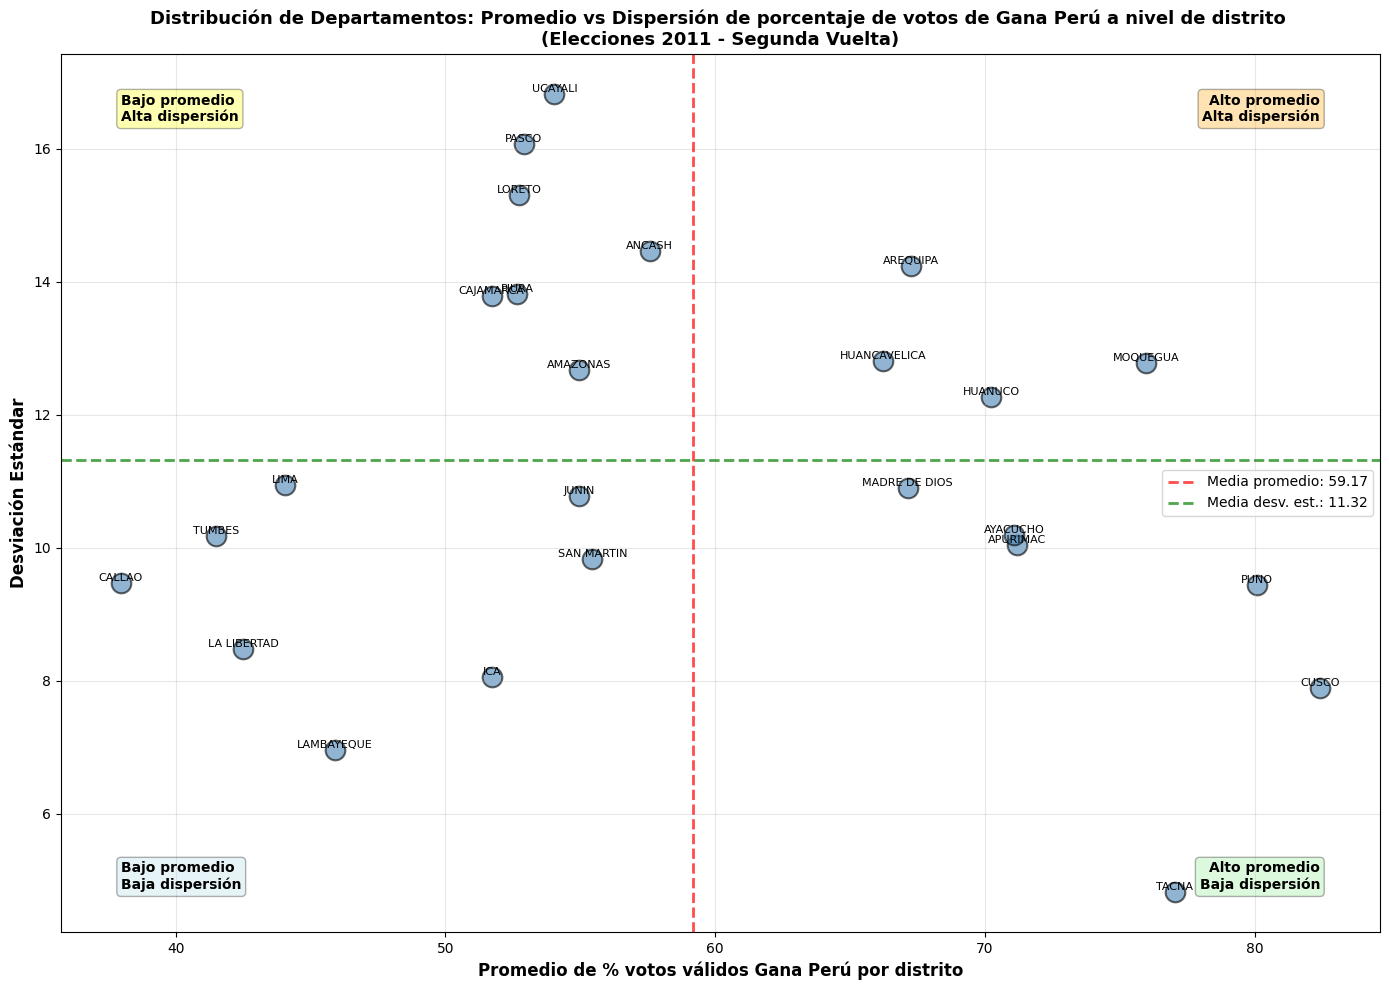

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

x = estadisticas_2011['promedio']
y = estadisticas_2011['desviacion_estandar']
departamentos = estadisticas_2011.index

ax.scatter(x, y, s=200, alpha=0.6, color='steelblue', edgecolors='black', linewidth=1.5)

for dept in departamentos:
    ax.annotate(dept, (x[dept], y[dept]), fontsize=8, ha='center', va='bottom')

# Líneas divisoras por la media de cada eje
media_x = x.mean()
media_y = y.mean()

ax.axvline(x=media_x, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Media promedio: {media_x:.2f}')
ax.axhline(y=media_y, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Media desv. est.: {media_y:.2f}')

# Etiquetas de cuadrantes
ax.text(x.min(), y.max(), 'Bajo promedio\nAlta dispersión', fontsize=10, fontweight='bold',
        va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
ax.text(x.max(), y.max(), 'Alto promedio\nAlta dispersión', fontsize=10, fontweight='bold',
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
ax.text(x.min(), y.min(), 'Bajo promedio\nBaja dispersión', fontsize=10, fontweight='bold',
        va='bottom', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(x.max(), y.min(), 'Alto promedio\nBaja dispersión', fontsize=10, fontweight='bold',
        va='bottom', ha='right', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

ax.set_xlabel('Promedio de % votos válidos Gana Perú por distrito', fontsize=12, fontweight='bold')
ax.set_ylabel('Desviación Estándar', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Departamentos: Promedio vs Dispersión de porcentaje de votos de Gana Perú a nivel de distrito \n(Elecciones 2011 - Segunda Vuelta)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()